# V11: 메뉴 텍스트 분석 및 월급날 피처를 결합한 고도화

이 노트북은 V10의 전략을 기반으로 **메뉴 선호도(키워드)**와 **월급날** 정보를 추가하여 60점대 진입을 목표로 합니다.

## 주요 전략
1. **메뉴 선호도 추출**: '돈까스', '고기', '튀김' 등 인기 메뉴의 빈도를 계산하여 피처화
2. **월급날(Payday) 피처**: 매월 25일 전후의 식수 패턴 변화 반영
3. **날씨 & 연휴 정교화**: 기온, 강수량(비온날) 및 연휴 전후 피처 유지
4. **CatBoost & XGBoost 앙상블**: 범주형 데이터에 강한 CatBoost 비중 확대


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None
from sklearn.metrics import mean_absolute_error
from korean_font import set_korean_font
import warnings
import re

set_korean_font()
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False


한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


In [7]:
# 1. 데이터 로드
train = pd.read_csv('data/train_median.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')
weather_train = pd.read_csv('data/weather.csv')
weather_test = pd.read_csv('data/weatherTest.csv')

# 2. 날씨 데이터 통합
weather = pd.concat([weather_train, weather_test], axis=0)
weather['일시'] = pd.to_datetime(weather['일시'])
weather['강수량'] = weather['강수량'].fillna(0)
weather['비온날'] = (weather['강수량'] > 0).astype(int)
weather = weather[['일시', '기온', '강수량', '비온날']]

# 3. 데이터 결합
train['일자'] = pd.to_datetime(train['일자'])
test['일자'] = pd.to_datetime(test['일자'])
train = pd.merge(train, weather, left_on='일자', right_on='일시', how='left')
test = pd.merge(test, weather, left_on='일자', right_on='일시', how='left')
train.drop(['일시'], axis=1, inplace=True)
test.drop(['일시'], axis=1, inplace=True)

print("데이터 로드 및 결합 완료")


데이터 로드 및 결합 완료


In [8]:
# 4. 메뉴 키워드 분석 및 피처 생성
def get_food_features(df):
    # 인기 키워드 (고기/튀김류)
    high_pref = ['돈까스', '고기', '불고기', '제육', '치킨', '스테이크', '닭', '오리', '삼겹살', '갈비']
    # 비인기 키워드 (나물류/건강식)
    low_pref = ['나물', '무침', '샐러드', '채소', '야채']
    
    def count_keywords(menu, keywords):
        count = 0
        for kw in keywords:
            if kw in menu:
                count += 1
        return count

    df['중식_선호메뉴'] = df['중식메뉴'].apply(lambda x: count_keywords(x, high_pref))
    df['중식_비선호메뉴'] = df['중식메뉴'].apply(lambda x: count_keywords(x, low_pref))
    df['석식_선호메뉴'] = df['석식메뉴'].apply(lambda x: count_keywords(x, high_pref))
    
    return df

train = get_food_features(train)
test = get_food_features(test)

# 월급날(25일) 피처
for df in [train, test]:
    df['월급날'] = (df['일자'].dt.day == 25).astype(int)
    # 월말 여부
    df['월말'] = (df['일자'].dt.is_month_end).astype(int)

print("메뉴 및 특수일 피처 생성 완료")


메뉴 및 특수일 피처 생성 완료


In [9]:
# 5. 연휴 및 참여율 생성
def add_basic_features(df):
    df['월'] = df['일자'].dt.month
    df['요일'] = df['일자'].dt.weekday
    df['일'] = df['일자'].dt.day
    df['식사가능자수'] = df['본사정원수'] - (df['본사휴가자수'] + df['본사출장자수'] + df['현본사소속재택근무자수'])
    
    # 연휴 전후
    df = df.sort_values('일자')
    df['일자간격'] = df['일자'].diff().dt.days
    df['공휴일후날'] = (df['일자간격'] > 2).astype(int)
    df['공휴일전날'] = (df['일자'].shift(-1).diff().dt.days > 2).astype(int)
    
    return df.fillna(0)

train = add_basic_features(train)
test = add_basic_features(test)

train['중식참여율'] = train['중식계'] / train['식사가능자수']
train['석식참여율'] = train['석식계'] / train['식사가능자수']


In [10]:
# 6. 모델링 (XGB + Cat)
features = ['월', '요일', '일', '식사가능자수', '본사출장자수', '본사시간외근무명령서승인건수', 
            '기온', '강수량', '비온날', '공휴일전날', '공휴일후날', '월급날', '월말', 
            '중식_선호메뉴', '중식_비선호메뉴', '석식_선호메뉴']

x_train = train[features]
x_test = test[features]

def train_and_ensemble(target):
    y_train = train[target]
    
    # XGB
    xgb = XGBRegressor(n_estimators=2000, learning_rate=0.01, max_depth=7, random_state=42)
    xgb.fit(x_train, y_train)
    p_xgb = xgb.predict(x_test)
    
    # Cat (CatBoost가 범주형/텍스트 기반 피처에 더 강함)
    if CatBoostRegressor:
        cat = CatBoostRegressor(n_estimators=2000, learning_rate=0.01, depth=7, random_state=42, verbose=0)
        cat.fit(x_train, y_train)
        p_cat = cat.predict(x_test)
        # CatBoost 비중을 0.6으로 상향 조정
        return p_xgb * 0.4 + p_cat * 0.6
    return p_xgb

print("예측 진행 중...")
test['pred_lunch'] = train_and_ensemble('중식참여율') * test['식사가능자수']
test['pred_dinner'] = train_and_ensemble('석식참여율') * test['식사가능자수']

submission['중식계'] = test['pred_lunch']
submission['석식계'] = test['pred_dinner']

# 날짜 순서 매핑으로 저장 (안전장치: 타입을 str로 일치시켜 ValueError 방지)
test['일자_str'] = test['일자'].dt.strftime('%Y-%m-%d')
sample_sub = pd.read_csv('data/sample_submission.csv')

final_sub = pd.merge(sample_sub[['일자']], 
                     test[['일자_str', 'pred_lunch', 'pred_dinner']], 
                     left_on='일자', right_on='일자_str', how='left')

final_sub = final_sub[['일자', 'pred_lunch', 'pred_dinner']]
final_sub.columns = ['일자', '중식계', '석식계']
final_sub.to_csv('submission/submission_v11.csv', index=False, encoding='utf-8-sig')

print("제출 파일 저장 완료: submission/submission_v11.csv")


예측 진행 중...
제출 파일 저장 완료: submission/submission_v11.csv


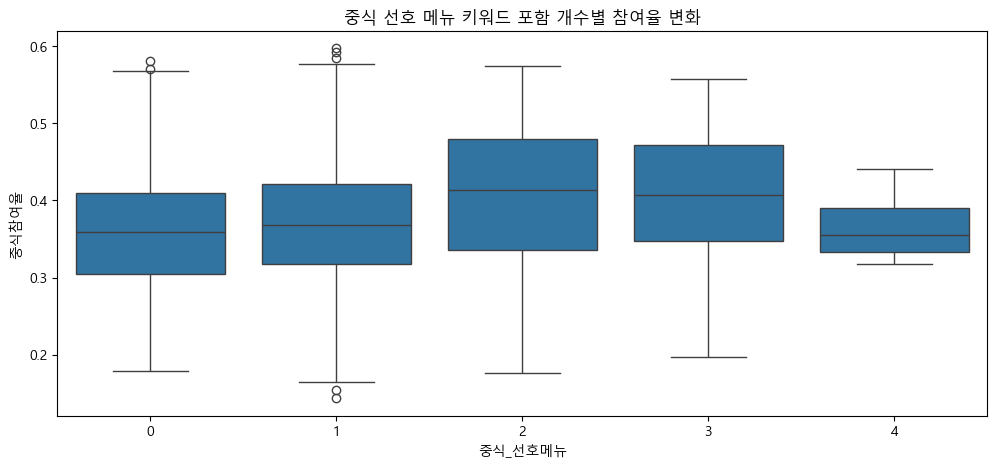

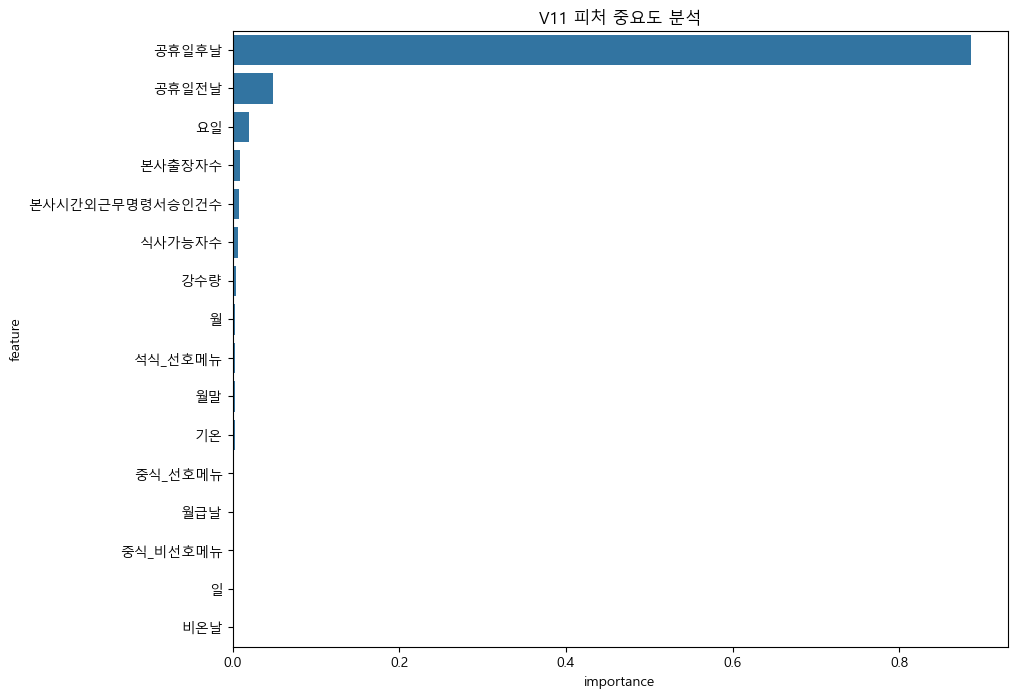

In [11]:
# 7. 시각화: 메뉴 선호도가 참여율에 미치는 영향
plt.figure(figsize=(12, 5))
sns.boxplot(data=train, x='중식_선호메뉴', y='중식참여율')
plt.title('중식 선호 메뉴 키워드 포함 개수별 참여율 변화')
plt.show()

# 피처 중요도 확인
importances = XGBRegressor().fit(x_train, train['중식참여율']).feature_importances_
fi = pd.DataFrame({'feature': features, 'importance': importances}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=fi, x='importance', y='feature')
plt.title('V11 피처 중요도 분석')
plt.show()
